<a href="https://colab.research.google.com/github/fa623/ml-code/blob/main/Spam_mail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
import kagglehub
path = kagglehub.dataset_download("nandhanasuresh/e-mail-spam-detection-dataset")
import os
path_df=os.path.join(path,"Spam_Data.csv")
df=pd.read_csv(path_df)
df.head()

100%|██████████| 206k/206k [00:00<00:00, 362kB/s]

Extracting files...


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Importing Dependencies

# Dataset Path

In [ ]:
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [ ]:
df.describe()

,Category,Message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [ ]:
df["Message"]=df["Message"].astype("category")
df["Message"]=df["Message"].cat.codes

In [ ]:
df["Message"]

,Message
0,1079
1,3101
2,1000
3,4088
4,2757
...,...
5567,3992
5568,4560
5569,3286
5570,3901


In [ ]:
df["Category"]=df["Category"].astype("category")
df["Category"]=df["Category"].cat.codes

In [ ]:
df["Category"]

,Category
0,0
1,0
2,1
3,0
4,0
...,...
5567,1
5568,0
5569,0
5570,0


In [ ]:
df

,Category,Message
0,0,1079
1,0,3101
2,1,1000
3,0,4088
4,0,2757
...,...,...
5567,1,3992
5568,0,4560
5569,0,3286
5570,0,3901


In [ ]:
 df.isnull().sum()

,0
Category,0
Message,0


In [ ]:
from sklearn.preprocessing import StandardScaler

X = df['Message']
y = df['Category']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train.values.reshape(-1, 1))
X_test_scaled = scaler.transform(X_test.values.reshape(-1, 1))

In [ ]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.8655


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9112


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(X_train_scaled,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = dt.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9058


In [ ]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [ ]:
y_pred_svm = svm_model.predict(X_test_scaled)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Model Accuracy: {accuracy_svm:.4f}")

SVM Model Accuracy: 0.8655


In [ ]:
prediction_on_training_data = model.predict(X_train_scaled)
accuracy_on_training_data = accuracy_score(y_train, prediction_on_training_data)
print('Accuracy on training data : ', accuracy_on_training_data)

Accuracy on training data :  0.8660533991474085


In [ ]:
prediction_on_testing_data=model.predict(X_test_scaled)
accuracy_on_testing_data=accuracy_score(y_test,prediction_on_testing_data)
print('Accuracy on testing data : ', accuracy_on_testing_data)

Accuracy on testing data :  0.8654708520179372


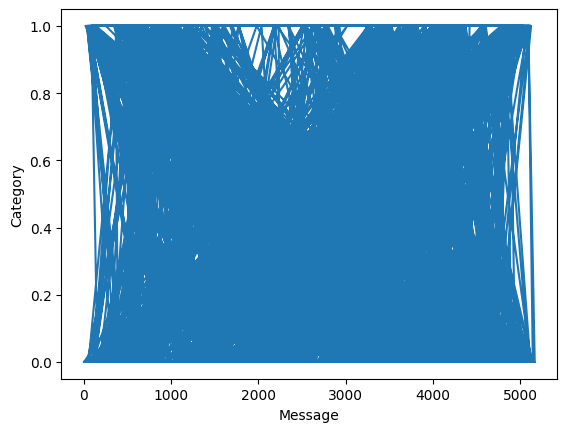

In [ ]:
plt.plot(df["Message"],df["Category"])
plt.xlabel("Message")
plt.ylabel("Category")
plt.show()

<Axes: xlabel='Message', ylabel='Category'>

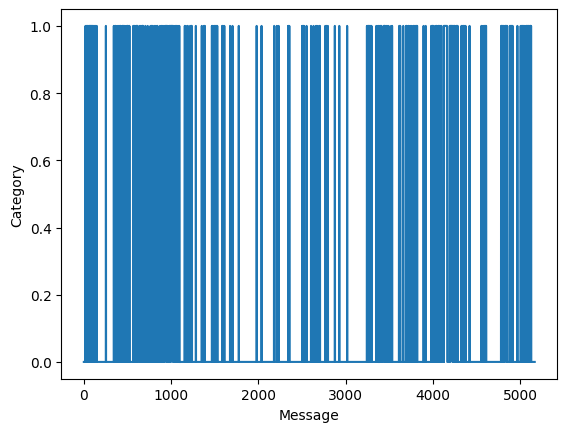

In [ ]:
sns.lineplot(data=df,x="Message",y="Category")

Text(0.5, 1.0, 'Box')

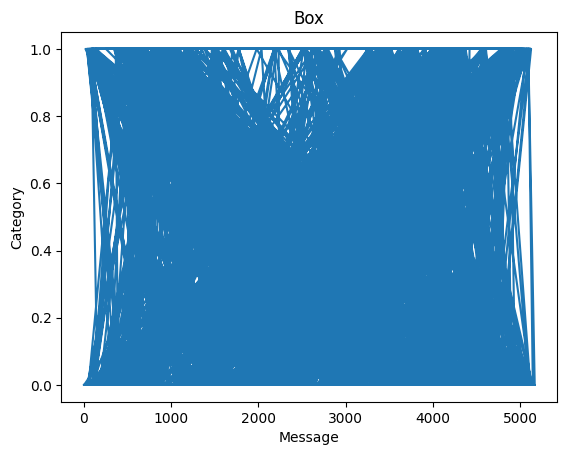

In [ ]:
plt.plot(df["Message"],df["Category"])
plt.xlabel("Message")
plt.ylabel("Category")
plt.title("Box")

<Axes: xlabel='Message', ylabel='Category'>

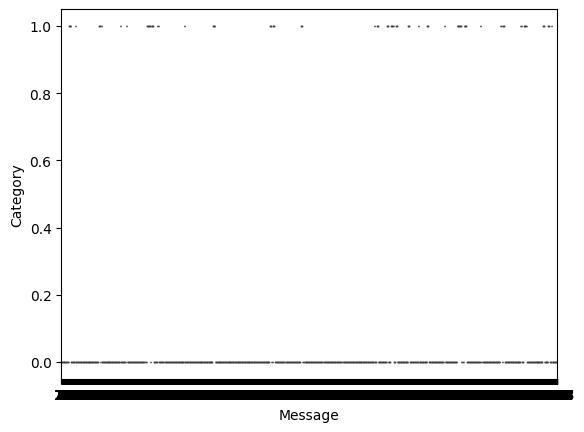

In [ ]:
sns.boxplot(data=df,x="Message",y="Category")


<Axes: >

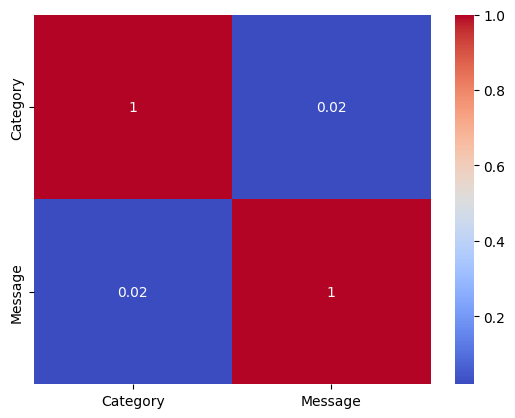

In [ ]:
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")

In [ ]:
# 1. Sabse pehle Gradio install karein (agar pehle se nahi hai)
!pip install -q gradio

import gradio as gr
import pandas as pd
import os
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# 2. Data load aur Model training pipeline setup karein
print("Data download aur model train ho raha hai, please wait...")
path = kagglehub.dataset_download("nandhanasuresh/e-mail-spam-detection-dataset")
path_df = os.path.join(path, "Spam_Data.csv")
df = pd.read_csv(path_df)

# Target variable ko encode karein (ham: 0, spam: 1)
df['Category'] = df['Category'].map({'ham': 0, 'spam': 1})

X = df['Message']
Y = df['Category']

# Text ko numbers mein convert karne ke liye TfidfVectorizer use karein
vectorizer = TfidfVectorizer(min_df=1, stop_words='english', lowercase=True)
X_features = vectorizer.fit_transform(X)

# Train-test split aur model training
X_train, X_test, Y_train, Y_test = train_test_split(X_features, Y, test_size=0.2, random_state=3)
model = LogisticRegression()
model.fit(X_train, Y_train)
print("Model training complete!")

# 3. Prediction Function jo GUI backend mein chalega (MODIFIED)
def check_spam(email_text):
    if not email_text.strip():
        return "⚠️ Please enter some text to check!"

    # Input text ko transform karein
    input_data_features = vectorizer.transform([email_text])

    # Prediction karein
    prediction = model.predict(input_data_features)

    # Sirf SPAM ya HAM return karein (Probability ko remove kar diya gaya hai)
    if prediction[0] == 1:
        return " SPAM"
    else:
        return "✅ HAM"

# 4. Gradio Interface (GUI Layout) design karein
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        """
        # 📧 Email Spam Detection Dashboard
        Apna email ya message niche box mein paste karein aur check karein ki wo **Spam** hai ya **Ham (Safe)**.
        """
    )

    with gr.Row():
        with gr.Column():
            input_text = gr.Textbox(
                label="Email Message Text",
                placeholder="Type or paste your email content here...",
                lines=6
            )
            submit_btn = gr.Button("🔍 Check Message", variant="primary")
            clear_btn = gr.ClearButton(components=[input_text])

        with gr.Column():
            output_result = gr.Textbox(
                label="Prediction Result",
                interactive=False,
                lines=2
            )

    # Button Actions
    submit_btn.click(fn=check_spam, inputs=input_text, outputs=output_result)
    input_text.submit(fn=check_spam, inputs=input_text, outputs=output_result)

# 5. Colab ke andar GUI launch karein
demo.launch(inline=True, share=True)